In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from pathlib import Path
import json
import subprocess

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

import mps
import pwexp

E0000 00:00:1784019705.846501   36318 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784019705.851456   36318 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784019705.864612   36318 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784019705.864637   36318 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784019705.864640   36318 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784019705.864643   36318 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784019710.277453   36318 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3734 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784019710.353122   36318 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3734 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784019710.390376   36318 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3734 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784019710.392500   36318 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3734 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


# Downloading OASIS data

### Metadata recovery

In [2]:
oasis_MR_info = pd.read_csv("OASIS Raw Data/OASIS3_MR_json.csv")

oasis_MR_info["day"] = oasis_MR_info["label"].str.split("_d").str[-1].astype("int")
oasis_MR_info["day"]

subject_id = "OAS30001"
oasis_MR_subject_info = oasis_MR_info.loc[ oasis_MR_info["subject_id"] == subject_id, : ].sort_values(by = "day")
oasis_MR_subject_info.loc[ oasis_MR_subject_info["scan category"] == "T1w", : ].iloc[0, :]

subject_id                      OAS30001
label                  OAS30001_MR_d0129
acccession                CENTRAL_E09253
release version             2018 Release
scan category                        T1w
                             ...        
PhaseEncodingAxis                    NaN
AcquisitionDateTime                  NaN
PhaseEncodingLines                   NaN
AccelFactPE                          NaN
day                                  129
Name: 16682, Length: 69, dtype: object

In [3]:
# Load all the metadata information about the MR scans for every patient in the OASIS-3 database
oasis_MR_info = pd.read_csv("OASIS Raw Data/OASIS3_Freesurfer_output.csv")

# Split the scans IDs to recover the day when each patient took each MR scan
oasis_MR_info["day"] = oasis_MR_info["MR_session"].str.split("_d").str[-1].astype("int")

# Filter only T1W scans and sort them by day
oasis_MR_info_sorted = oasis_MR_info.sort_values(by = ["Subject", "day", "FS_FSDATA ID"])

# Select only the first observation for each subject. That corresponds to their first ever MR scan
baseline_scans_group = oasis_MR_info_sorted.groupby("Subject").first().reset_index()

final_metadata_MR = baseline_scans_group.loc[:, ["Subject", "day", "FS_FSDATA ID"]]
final_metadata_MR["MR ID"] = final_metadata_MR["FS_FSDATA ID"].str.split("_").apply(lambda x: f"{x[0]}_MR_{x[2]}")

final_metadata_MR.to_csv("OASIS Raw Data/MR_earliest_scans_info.csv", index = False)

display( final_metadata_MR.head() )

,Subject,day,FS_FSDATA ID,MR ID
0,OAS30001,129,OAS30001_Freesurfer53_d0129,OAS30001_MR_d0129
1,OAS30002,371,OAS30002_Freesurfer50_d0371,OAS30002_MR_d0371
2,OAS30003,558,OAS30003_Freesurfer53_d0558,OAS30003_MR_d0558
3,OAS30004,1101,OAS30004_Freesurfer53_d1101,OAS30004_MR_d1101
4,OAS30005,143,OAS30005_Freesurfer51_d0143,OAS30005_MR_d0143


### Brain MRI download

Once the earliest MR scans of interest have been defined, we can call the NITR database dynamically and download only the files of our interest. In this case, we are interested in gathering both the numerical variables from Freesurfer (tabular data for future studies) and the proper images, which we will be considering here to be from brainmask.mgz

In [4]:
import urllib3
import xnat
import logging
import pandas as pd
import os
import sys
import getpass
from contextlib import redirect_stdout, redirect_stderr

df_earliest_scans = pd.read_csv("OASIS Raw Data/MR_earliest_scans_info.csv")

# Create data directory if it doesn't exist
os.makedirs("./OASIS Raw Data/brainmasks", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:
    subject_id = "OAS30001"
    fs_id = "OAS30001_Freesurfer53_d0129"
    mr_id = fs_id.replace("Freesurfer53", "MR")
    try:
        print("Accessing MR Session: {}...".format(mr_id))
        mr_session = project.subjects[subject_id].experiments[mr_id]
        print("Accessing FreeSurfer Assessor: {}...".format(fs_id))
        fs_assessor = mr_session.assessors[fs_id]
        
        # Continue to find the path if next directory is "resources" or "out"
        if hasattr(fs_assessor, "resources") and fs_assessor.resources:
            res_collection = fs_assessor.resources
        elif hasattr(fs_assessor, "out") and fs_assessor.out:
            res_collection = fs_assessor.out
        # If resources do not exist, list the available attributes inside fs_assessor
        else:
            print("Could not locate the resources folder. Available attributes are:")
            print([a for a in dir(fs_assessor) if not a.startswith('_')])
            res_collection = {}
            
        # Search for brainmask.mgz inside res_collection
        target_file = None
        for resource_name, resource in res_collection.items():
            # Safely check if this resource actually has files
            if(hasattr(resource, "files")):
                for file_path, file_obj in resource.files.items():
                    # Dynamically search for a file whose name ends with "brainmask.mgz"
                    if file_path.endswith("brainmask.mgz"):
                        target_file = file_obj
                        print("Found target: {} in [{}]".format(file_path, resource_name))
                        break
            if target_file:
                break
                
        # Download the specific file
        if target_file:
            save_path = "./OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id)
            print("Downloading to {}...".format(save_path))
            with open(os.devnull, 'w') as fnull:
                with redirect_stdout(fnull), redirect_stderr(fnull):
                    target_file.download(save_path)
            print("Download complete!")
        else:
            print("Could not find brainmask.mgz inside the assessor.")

    except KeyError as e:
        print(f"Warning: Could not find node {e} on the server.")

Enter NITRC password:  ········


Accessing MR Session: OAS30001_MR_d0129...
Accessing FreeSurfer Assessor: OAS30001_Freesurfer53_d0129...
Found target: OAS30001_MR_d0129/mri/brainmask.mgz in [123279552]


100% of   1.1 MiB |################################|   2.8 MiB/s Time:  0:00:0000


Download complete!


The above code successfully retrieves the brainmask.mgz file for a single patient OAS30001. Below, we implement the code to download all the MRI brain scan images for our study.

In [5]:
from tqdm import tqdm

df_earliest_scans = pd.read_csv("OASIS Raw Data/MR_earliest_scans_info.csv")

# Create data directory if it doesn't exist
os.makedirs("./OASIS Raw Data/brainmasks", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:

    # for i for tqdm(range( df_earliest_scans.shape[0] )):
    for i in range( 3 ):
        subject_id = df_earliest_scans.loc[i,"Subject"]
        fs_id = df_earliest_scans.loc[i,"FS_FSDATA ID"]
        mr_id = df_earliest_scans.loc[i,"MR ID"]
        try:
            mr_session = project.subjects[subject_id].experiments[mr_id]
            fs_assessor = mr_session.assessors[fs_id]
            
            # Continue to find the path if next directory is "resources" or "out"
            if hasattr(fs_assessor, "resources") and fs_assessor.resources:
                res_collection = fs_assessor.resources
            elif hasattr(fs_assessor, "out") and fs_assessor.out:
                res_collection = fs_assessor.out
            # If resources do not exist, list the available attributes inside fs_assessor
            else:
                res_collection = {}
                
            # Search for brainmask.mgz inside res_collection
            target_file = None
            for resource_name, resource in res_collection.items():
                # Safely check if this resource actually has files
                if(hasattr(resource, "files")):
                    for file_path, file_obj in resource.files.items():
                        # Dynamically search for a file whose name ends with "brainmask.mgz"
                        if file_path.endswith("brainmask.mgz"):
                            target_file = file_obj
                            break
                if target_file:
                    break
                    
            # Download the specific file
            if target_file:
                save_path = "./OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id)
                with open(os.devnull, 'w') as fnull:
                    with redirect_stdout(fnull), redirect_stderr(fnull):
                        target_file.download(save_path)
    
        except KeyError as e:
            print("Error downloading {} MRI image!".format(subject_id))

Enter NITRC password:  ········


100% of   1.1 MiB |################################|   3.2 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   3.1 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   5.0 MiB/s Time:  0:00:0000


### Subject demographics and Freesurfer tabular data

In [ ]:
# Merge information with patient-specific demographic data
oasis_demographics = pd.read_csv("OASIS Raw Data/OASIS3_demographics.csv")
# Filter only columns of interest for the analysis
oasis_demographics = oasis_demographics.loc[:, ["OASISID", "AgeatEntry", "AgeatDeath", "GENDER", "APOE"]]

final_metadata_MR = pd.merge(baseline_scans_group, oasis_demographics, left_on = "Subject", right_on = "OASISID", how = "inner")

In [157]:
oasis_demographics

,OASISID,Subject_accession,AgeatEntry,AgeatDeath,GENDER,EDUC,SES,racecode,race,ETHNIC,AIAN,NHPI,ASIAN,AA,WHITE,daddem,momdem,HAND,APOE
0,OAS30001,NaN,65.1945,NaN,2,12.0,4.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,R,23.0
1,OAS30002,NaN,67.2521,76.9397,1,18.0,2.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,R,34.0
2,OAS30003,NaN,58.8137,NaN,2,18.0,1.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,R,33.0
3,OAS30004,NaN,55.1342,NaN,2,17.0,1.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,L,23.0
4,OAS30005,NaN,48.0630,NaN,2,16.0,3.0,2,ASIAN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,R,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1373,OAS31470,NaN,64.9096,NaN,2,14.0,2.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,R,34.0
1374,OAS31471,NaN,65.2986,NaN,1,18.0,2.0,4,Black,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,R,34.0
1375,OAS31472,NaN,67.2712,NaN,2,18.0,1.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,R,33.0
1376,OAS31473,NaN,56.6137,NaN,1,20.0,1.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,R,34.0


# Pre-processing

(256, 256, 256)


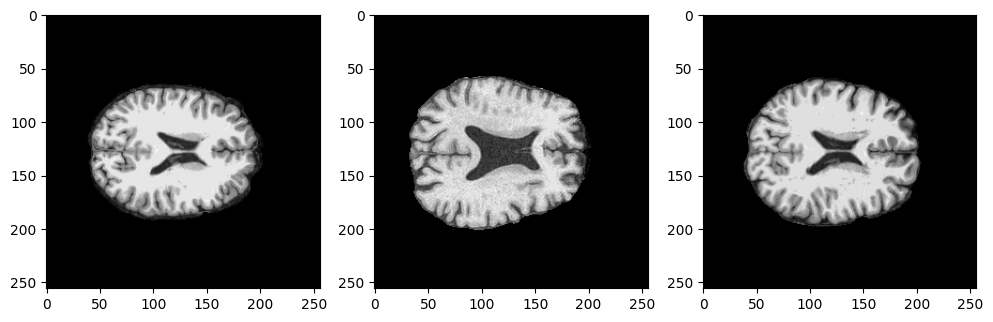

In [10]:
import nibabel as nib

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

img1 = nib.load("OASIS Raw Data/brainmasks/OAS30001_brainmask.mgz")
img2 = nib.load("OASIS Raw Data/brainmasks/OAS30002_brainmask.mgz")
img3 = nib.load("OASIS Raw Data/brainmasks/OAS30003_brainmask.mgz")

brain1 = img1.get_fdata()
brain2 = img2.get_fdata()
brain3 = img3.get_fdata()
print(brain1.shape)

middle_slice1 = brain1[:, 110, :]
middle_slice2 = brain2[:, 110, :]
middle_slice3 = brain3[:, 110, :]

ax[0].imshow( middle_slice1, cmap = "gray" )
ax[1].imshow( middle_slice2, cmap = "gray" )
ax[2].imshow( middle_slice3, cmap = "gray" )

plt.show()

In [102]:
import xml.etree.ElementTree as ET

xml_path = "OASIS Raw Data/07_14_26_02_40_28.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

# XNAT/FreeSurfer uses the 'fs' namespace for its volumetric measures
namespaces = {'fs': 'http://nrg.wustl.edu/fs'}
data = {}

# Extract the Subject/Session ID from the root attributes
session_label = root.attrib.get('label')
data['Session_ID'] = session_label

if session_label:
    data['Subject_ID'] = session_label.split('_')[0]

num_quantities = ["GDS", "ICV", "lhCortexVol", "rhCortexVol", "CortexVol",
                  "SubCortGrayVol", "TotalGrayVol", "SupraTentorialVol", "lhCorticalWhiteMatterVol",
                  "rhCorticalWhiteMatterVol", "CorticalWhiteMatterVol",
                  "TRAUMBRF", "TRAUMEXT", "SMOKYRS", "PACKSPER"]

for col in num_quantities:
    node = root.find(".//fs:{}".format(col), namespaces)
    data[col] = float(node.text) if node is not None else None
print(data)

{'Session_ID': 'OAS30003_Freesurfer53_d0558', 'Subject_ID': 'OAS30003', 'GDS': None, 'ICV': 1449811.051977, 'lhCortexVol': 206641.011307, 'rhCortexVol': 214696.395609, 'CortexVol': 421337.406916, 'SubCortGrayVol': 59540.0, 'TotalGrayVol': 569622.406916, 'SupraTentorialVol': 953803.462384, 'lhCorticalWhiteMatterVol': 226794.049522, 'rhCorticalWhiteMatterVol': 229032.005946, 'CorticalWhiteMatterVol': 455826.055467, 'TRAUMBRF': None, 'TRAUMEXT': None, 'SMOKYRS': None, 'PACKSPER': None}


In [28]:
img_train.shape

(281, 160, 200, 1)

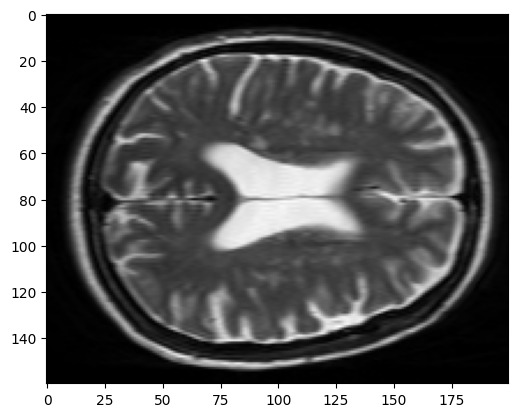

In [71]:
plt.imshow( img_train[230], cmap = "gray" )

In [20]:
data_train["time"].iloc[231]

np.float64(6.10958904109589)

In [104]:
tf.clip_by_value(2.0, 0.0, np.inf)

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

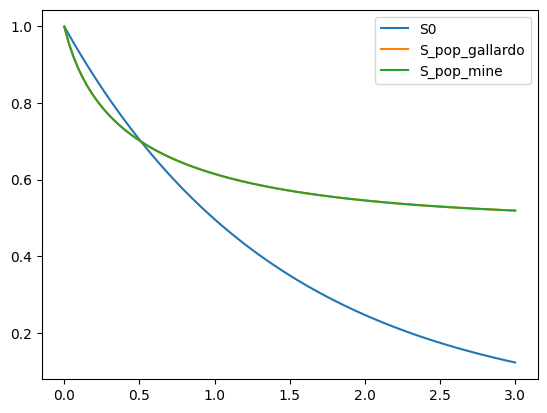

In [101]:
m = np.arange(0, 51).astype("float")

theta = 0.7

t = np.linspace(0, 3, 100)[:,None]
S_0 = lambda t, lam : np.exp( - lam * t )

S_pop_t = np.exp(-theta) * np.sum( (m+1)**(m-1) * ( theta*np.exp(-theta)*S_0(t, theta) )**m / np.exp(loggamma(m+1)), axis = 1 )

t_flat = t.flatten()

plt.plot( t_flat, S_0(t_flat, theta), label = "S0" )
plt.plot(t_flat, S_pop_t, label = "S_pop_gallardo")

phi = lambda theta : theta * np.exp(-theta)
phi_inv = lambda u : -lambertw(-u).real

num = np.exp( phi_inv( S_0(t, theta) * phi(theta) ) )
den = np.exp( theta )
plt.plot(t_flat, num / den, label = "S_pop_mine")

plt.legend()

plt.show()

In [67]:
(m+1)**(m-1)

array([1.00000000e+00, 1.00000000e+00, 3.00000000e+00, 1.60000000e+01,
       1.25000000e+02, 1.29600000e+03, 1.68070000e+04, 2.62144000e+05,
       4.78296900e+06, 1.00000000e+08, 2.35794769e+09, 6.19173642e+10,
       1.79216039e+12, 5.66939124e+13, 1.94619507e+15, 7.20575940e+16,
       2.86242305e+18, 1.21439531e+20, 5.48038686e+21, 2.62144000e+23,
       1.32484966e+25, 7.05429499e+26, 3.94715841e+28, 2.31551350e+30,
       1.42108547e+32, 9.10668577e+33, 6.08266788e+35, 4.22774530e+37,
       3.05313455e+39, 2.28767925e+41, 1.77618878e+43, 1.42724769e+45,
       1.18558347e+47, 1.01701029e+49, 9.00006122e+50, 8.20890115e+52,
       7.71010588e+54, 7.45091276e+56, 7.40270529e+58, 7.55578637e+60,
       7.91717805e+62, 8.51082412e+64, 9.38008295e+66, 1.05928400e+69,
       1.22500565e+71, 1.44992185e+73, 1.75551121e+75, 2.17318610e+77,
       2.74925967e+79, 3.55271368e+81, 4.68747138e+83])